In [1]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [4]:
#Android App Telegram  from Google Play at
#https://play.google.com/store/apps/details?id=org.telegram.messenger
#ID Apps:
#The apps ID found in the link after id=org.telegram.messenger
#The apps name on Google Play titled: Telegram
#Dated 17 March 2026 and N of reviews 16.7m

from google_play_scraper import reviews, Sort

tele_reviews, _ = reviews(
    'org.telegram.messenger',
    lang='id',
    sort=Sort.NEWEST,
    count=100000  # batas 100k
)

len(tele_reviews)

100000

In [8]:
#Save Telegram reviews into dataframe
df_telerev = pd.DataFrame(np.array(tele_reviews),columns=['content'])
df_telerev = df_telerev.join(pd.DataFrame(df_telerev.pop('content').tolist()))
df_telerev.to_csv(r'df_telerev.csv', index=False)

In [13]:
print(df_telerev.shape)

(100000, 11)


In [6]:
df_telerev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              100000 non-null  object        
 1   userName              100000 non-null  object        
 2   userImage             100000 non-null  object        
 3   content               100000 non-null  object        
 4   score                 100000 non-null  int64         
 5   thumbsUpCount         100000 non-null  int64         
 6   reviewCreatedVersion  65479 non-null   object        
 7   at                    100000 non-null  datetime64[ns]
 8   replyContent          29036 non-null   object        
 9   repliedAt             29036 non-null   datetime64[ns]
 10  appVersion            65479 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 8.4+ MB


In [7]:
df_telerev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b6cb4c8f-60a7-48e5-a6c8-945480ce4888,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,malah berbayar,1,0,12.5.1,2026-03-16 13:17:55,None,NaT,12.5.1
1,18d661cf-8c17-487d-9223-5a60909511c2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,daftar akun harus premium,1,0,None,2026-03-16 12:47:10,None,NaT,None
2,dbf6ed43-961c-4ab2-a913-30cf7c1d411c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,masa dftar akun hrus byr🤣🤣🤣,1,0,12.5.1,2026-03-16 12:38:20,None,NaT,12.5.1
3,772026f9-e4d5-4550-bb5a-e10323751c2e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,KENAPA TELEGRAM SAYA SERING FORCE CLOSEEE,1,0,12.5.1,2026-03-16 12:06:50,Maaf atas masalah yang Anda alami. Silakan lap...,2026-03-16 13:16:05,12.5.1
4,058a6794-358f-4532-a7a2-9c4550ee491a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,di paksa premium,1,0,None,2026-03-16 11:30:10,None,NaT,None


In [10]:
# Distribution of reviews score
df_telerev['score'].value_counts()

,count
score,
1,55986
5,27795
2,6903
3,5222
4,4094


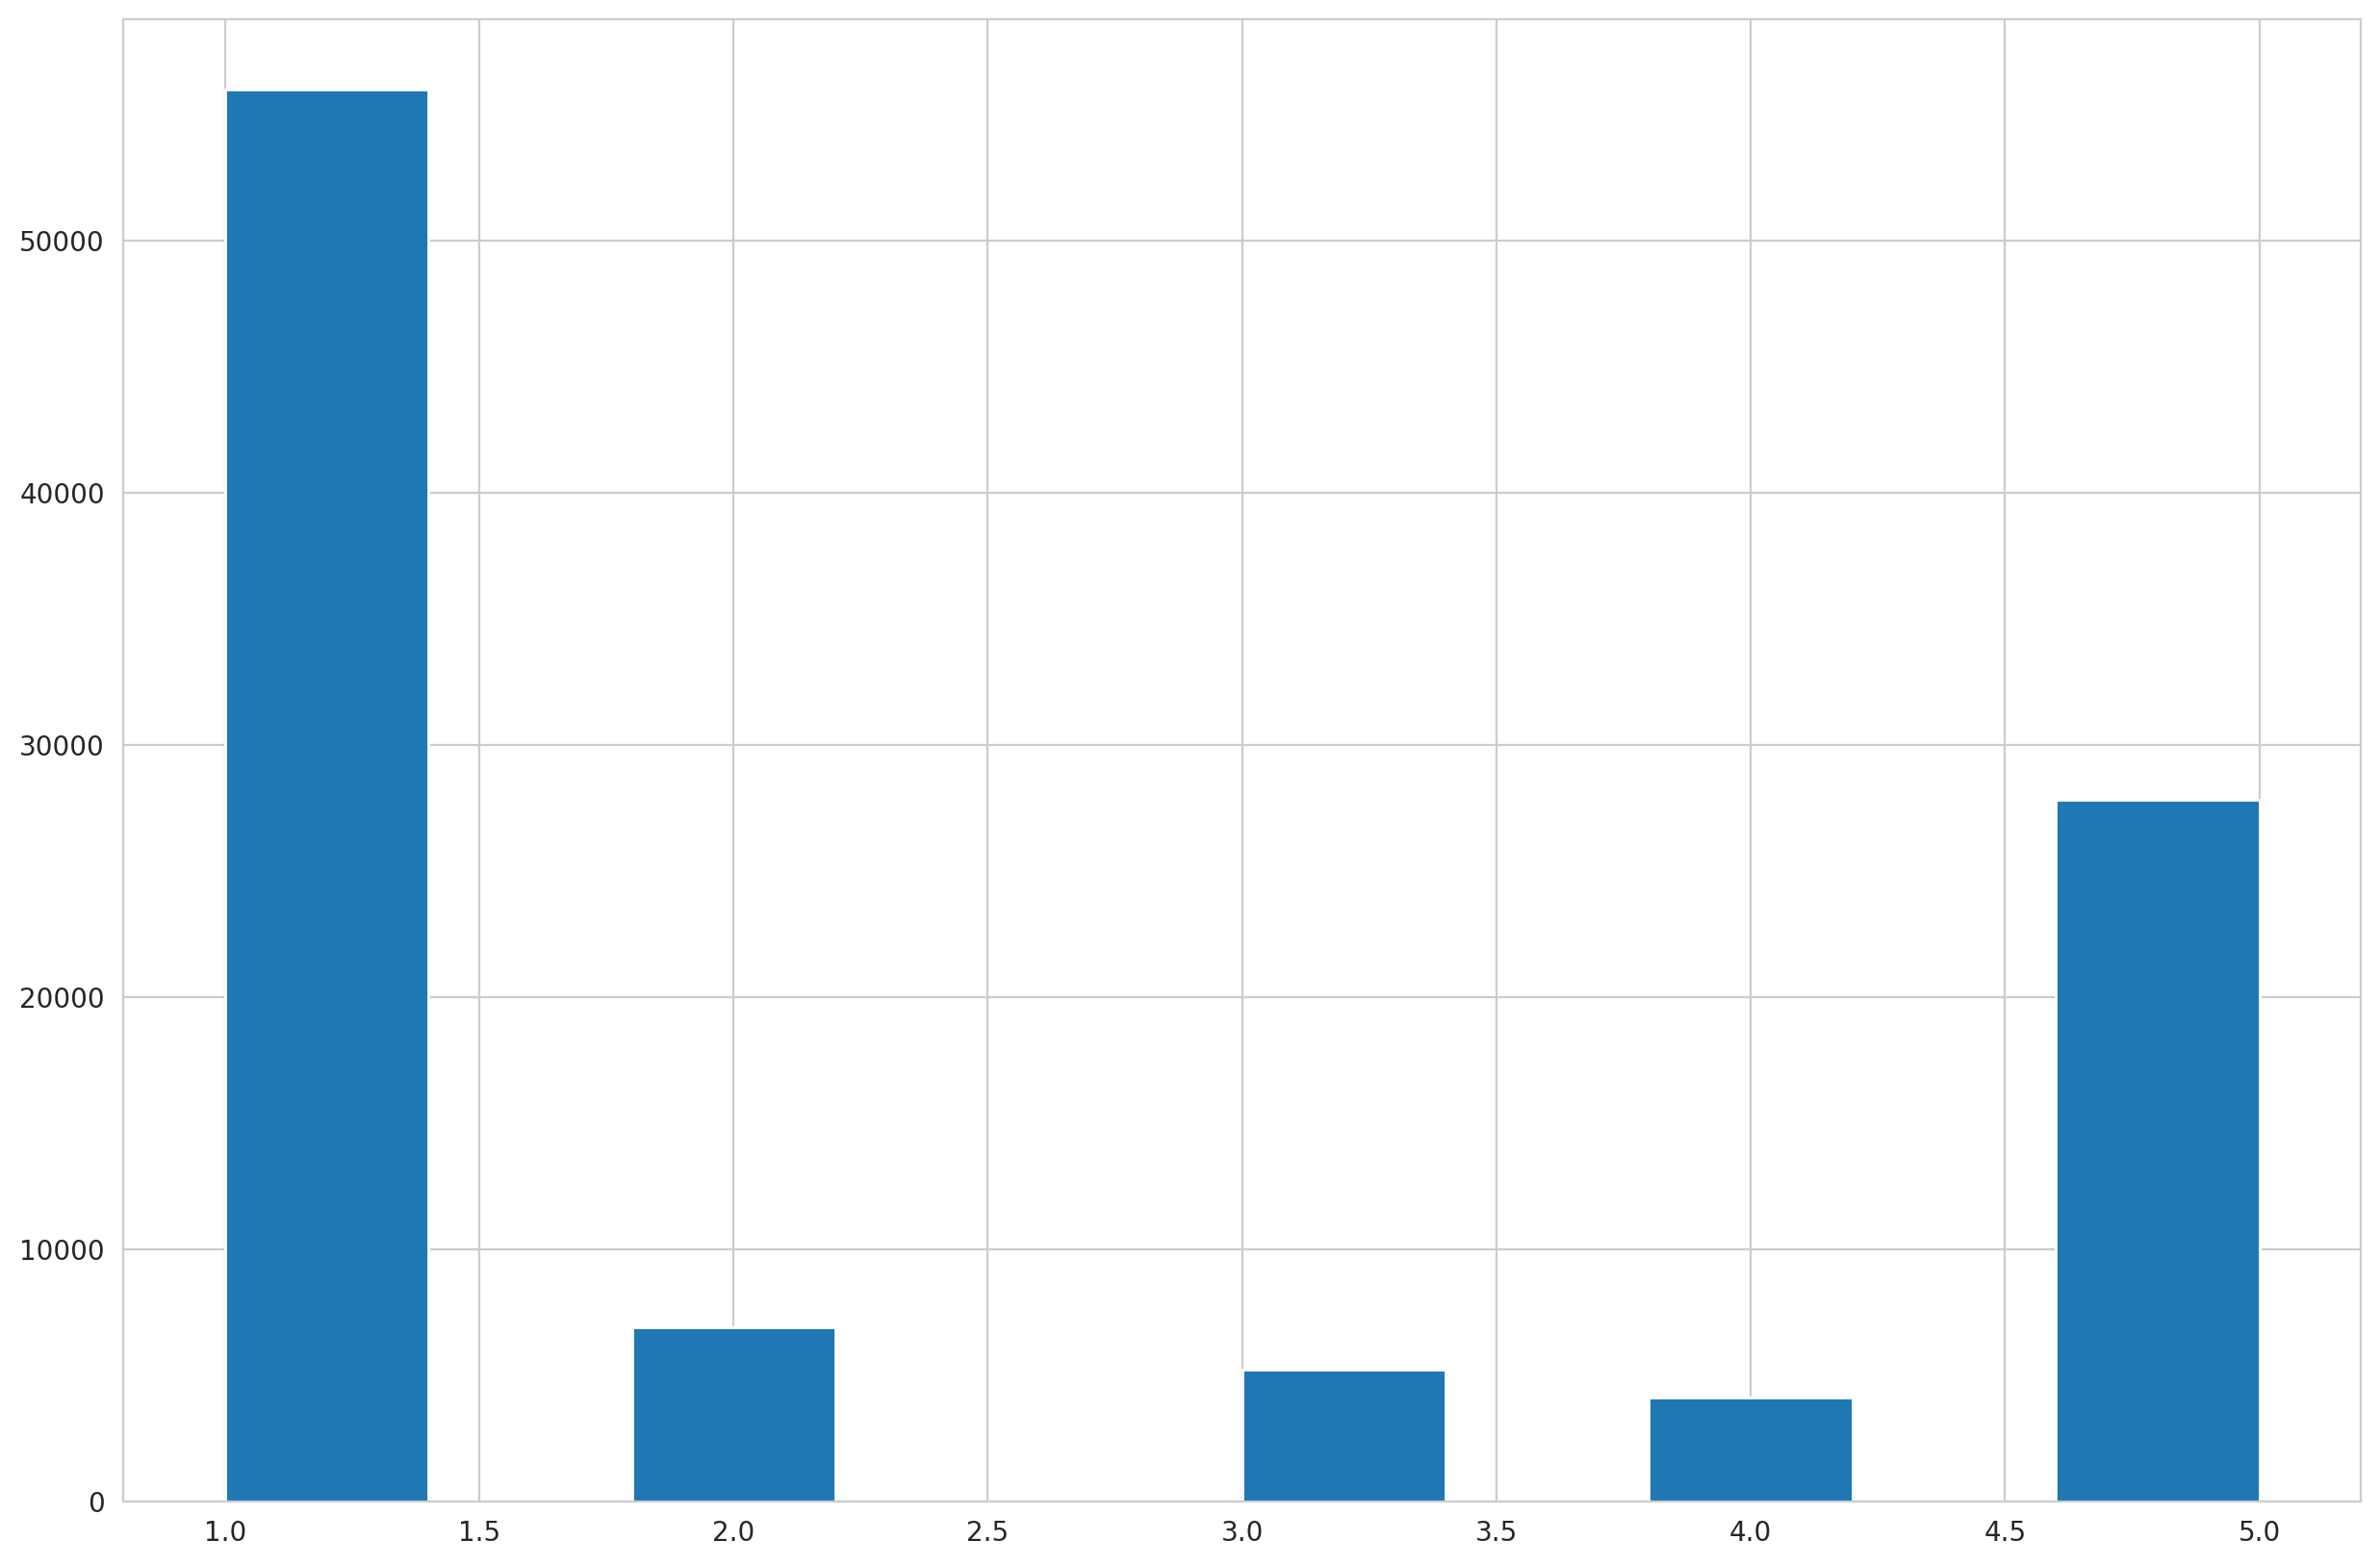

In [11]:
plt.hist(df_telerev['score'])
plt.show()